# Multilevel models

Grouped data are the rule, not the exception -- patients within hospitals, students within schools,
measurements within counties, repeated observations within subjects -- and analysing them well is the central
skill of applied statistics. We work through multilevel (mixed-effects, hierarchical) modelling,
worked on the dataset that defined the subject: home radon measurements across Minnesota's 85 counties
(Gelman and Hill). We build from the bias-variance logic of pooling through varying intercepts and slopes,
variance components, group-level predictors and contextual effects, the within/between decomposition and the
ecological fallacy, parameterisation and the funnel, predictive model comparison, partial pooling for
non-Gaussian outcomes, and nested three-level models -- exercising mixle's mixed-effects regression and
conjugate hierarchical estimators throughout. Modelling is the point; plotting is confined to a small helper.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mixle.ppl import Normal, Field, Group, free, Bernoulli, Beta, Poisson, Gamma
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
df = pd.read_csv('../../data/radon/radon_mn.csv')
y = list(df['log_radon']); floor = list(df['floor']); county = list(df['county'])
sizes = df.groupby('county').size()
print('%d homes, %d counties; county sizes %d-%d (median %d); response = log radon' %
      (len(df), df['county'].nunique(), sizes.min(), sizes.max(), int(sizes.median())))

919 homes, 85 counties; county sizes 1-116 (median 5); response = log radon


## 1. The pooling problem

We want a radon estimate for each county, and the floor effect (basement vs first floor). Three strategies
bracket the choices. Complete pooling fits one regression to all homes, ignoring counties -- stable but biased,
since counties genuinely differ in their soil. No pooling fits a separate intercept per county -- unbiased per
county but hopeless for the many counties with one or two homes, where the estimate is pure noise. Partial
pooling, the multilevel compromise, treats the county intercepts as draws from a population and shrinks each
toward the state mean by an amount set by its own evidence. The whole course is the theory and practice of
that compromise; we begin by quantifying how badly the two extremes fail.

In [2]:
base = df[df['floor'] == 0]; grand = base['log_radon'].mean()
nopool = base.groupby('county')['log_radon'].mean()
ns = np.array([sizes[c] for c in nopool.index]); dev = nopool.values - grand
print('no pooling: county-mean deviation std is %.2f for small counties (n<=3) but %.2f for large (n>=30)'
      % (np.std(dev[ns <= 3]), np.std(dev[ns >= 30])))
print('the small-county estimates fan out to noisy extremes -- overfitting; complete pooling forces them all to %.2f' % grand)

no pooling: county-mean deviation std is 0.51 for small counties (n<=3) but 0.21 for large (n>=30)
the small-county estimates fan out to noisy extremes -- overfitting; complete pooling forces them all to 1.36


## 2. The varying-intercept model

The varying-intercept model places the county intercepts on a shared population:
$\log\text{radon}_i = \alpha_{j[i]} + \beta\,\text{floor}_i + \varepsilon_i$, with
$\alpha_j\sim\mathcal N(\mu_\alpha,\tau^2)$ and $\varepsilon_i\sim\mathcal N(0,\sigma^2)$. Treating the
intercepts as a sample rather than 85 free numbers couples the counties and produces partial pooling. In
mixle it is `free*Field('floor') + free + Group('county')` -- a fixed floor slope and state intercept
plus a partially-pooled county random intercept -- fit by linear-mixed-model EM, returning the fixed effects,
the variance components, and the per-county BLUPs.

In [3]:
m = Normal(free * Field('floor') + free + Group('county'), free).fit(y, given={'floor': floor, 'county': county})
fe = m.result.coefficients; tau, sigma = m.result.tau, m.result.sigma
print('floor effect %.3f (first-floor homes ~%.0f%% lower); state intercept %.3f'
      % (fe['floor']['mean'], 100 * (1 - np.exp(fe['floor']['mean'])), fe['intercept']['mean']))
print('variance components: between-county tau=%.3f, within-county sigma=%.3f' % (tau, sigma))

floor effect -0.663 (first-floor homes ~48% lower); state intercept 1.492
variance components: between-county tau=0.312, within-county sigma=0.725


## 3. Variance components, the intraclass correlation, and the shrinkage formula

The variance components answer where the variation lives. The intraclass correlation
$\mathrm{ICC}=\tau^2/(\tau^2+\sigma^2)$ is the fraction between counties -- equivalently the correlation
between two homes in the same county. It also sets the shrinkage: a county with $n_j$ homes has its mean
pulled toward the state by $1-\tau^2/(\tau^2+\sigma^2/n_j)$, near zero for large $n_j$, near one for small.
We compute the ICC and verify the multilevel intercepts match this analytic shrinkage of the no-pooling
means -- the model is doing exactly the precision-weighting the formula prescribes.

In [4]:
icc = tau ** 2 / (tau ** 2 + sigma ** 2); ge = m.result.group_effects
b0s = fe['intercept']['mean']; bfl = fe['floor']['mean']
resid = df['log_radon'].values - bfl * df['floor'].values                       # remove the fixed floor effect
np_int = pd.Series(resid, index=df.index).groupby(df['county']).mean()          # floor-adjusted no-pooling county intercept
rows = [(sizes[c], np_int[c] - b0s, ge[c]) for c in ge if c in np_int.index]
nn, npd, ppd = map(np.array, zip(*rows))
analytic = (nn * tau ** 2 / (nn * tau ** 2 + sigma ** 2)) * npd                  # precision-weighted shrink of the no-pool deviation
print('ICC = %.2f (%.0f%% of variance is between counties)' % (icc, 100 * icc))
print('multilevel intercepts vs the analytic shrinkage formula: max abs difference %.3f (they coincide)'
      % np.max(np.abs(ppd - analytic)))
print('mean |deviation from state|: no pooling %.3f -> partial pooling %.3f (the small counties are pulled in)'
      % (np.abs(npd).mean(), np.abs(ppd).mean()))

ICC = 0.16 (16% of variance is between counties)
multilevel intercepts vs the analytic shrinkage formula: max abs difference 0.000 (they coincide)
mean |deviation from state|: no pooling 0.373 -> partial pooling 0.182 (the small counties are pulled in)


## 4. Varying slopes

The floor effect need not be constant across counties -- the basement-to-first-floor drop could vary with
local housing. A varying-slope model lets each county have its own floor effect, drawn jointly with its
intercept from a population: `Group('county', slopes=['floor'])`, the analogue of `(1 + floor | county)`. The
model estimates how much the slope varies and the intercept-slope correlation. With sparse within-county floor
contrasts the slope variation is small here -- a finding in itself (the floor effect is nearly universal), and
a reminder that adding random slopes is a hypothesis to be tested, not a default.

In [5]:
ms = Normal(free * Field('floor') + free + Group('county', slopes=['floor']), free).fit(y, given={'floor': floor, 'county': county})
print('varying-slope model: mean floor effect %.3f; within-county sigma %.3f (intercept-only) vs %.3f (with random slope)'
      % (ms.result.coefficients['floor']['mean'], sigma, ms.result.sigma))
print('the random-slope model barely lowers sigma, so the floor effect is close to constant across counties')

varying-slope model: mean floor effect -0.656; within-county sigma 0.725 (intercept-only) vs 0.717 (with random slope)
the random-slope model barely lowers sigma, so the floor effect is close to constant across counties


## 5. Group-level predictors and contextual effects

Counties differ for reasons we can sometimes measure. Soil uranium is the geological source of radon, and it
is a county-level (group) predictor -- constant within a county. Adding it explains part of the between-county
variation rather than absorbing it into $\tau$: the celebrated radon-uranium model reveals a strong
uranium-radon relationship and shrinks the residual $\tau$, showing that what looked like idiosyncratic county
differences is largely geology. This is the contextual effect, and it is how multilevel models combine
individual- and group-level information.

In [6]:
mu_ = Normal(free * Field('floor') + free * Field('uranium') + free + Group('county'), free).fit(
        y, given={'floor': floor, 'uranium': list(df['Uppm']), 'county': county})
feu = mu_.result.coefficients
print('uranium effect %.3f per unit soil uranium; floor effect %.3f' % (feu['uranium']['mean'], feu['floor']['mean']))
print('between-county tau: %.3f (no uranium) -> %.3f (with uranium) -- geology explains much of the county variation'
      % (tau, mu_.result.tau))

uranium effect 0.775 per unit soil uranium; floor effect -0.636


between-county tau: 0.312 (no uranium) -> 0.141 (with uranium) -- geology explains much of the county variation


## 6. The within/between decomposition and the ecological fallacy

A subtle trap: a relationship between county-averaged variables need not hold for individual homes, and the
two can even point in opposite directions (Simpson's paradox). The fix is to separate a predictor's within-
group part (deviation from its county mean) from its between-group part (the county mean itself) and give them
their own coefficients -- the contextual / within-between formulation. We construct a predictor with opposite
within- and between-county associations and show that a naive single-coefficient model recovers the wrong
(between) sign while the decomposition recovers both correctly, the formal cure for the ecological fallacy.

In [7]:
# build a covariate x with a positive WITHIN-county slope but a negative BETWEEN-county slope on log_radon
cmean_r = df.groupby('county')['log_radon'].transform('mean').values
devr = df['log_radon'].values - cmean_r
x = 1.0 * devr - 1.0 * cmean_r + 0.1 * rng.randn(len(df))       # within part follows the deviation (+), between part anti-follows the county mean (-)
xbar = pd.Series(x, index=df.index).groupby(df['county']).transform('mean')
naive = Normal(free * Field('x') + free + Group('county'), free).fit(y, given={'x': list(x), 'county': county})
wb = Normal(free * Field('xw') + free * Field('xb') + free + Group('county'), free).fit(
        y, given={'xw': list(x - xbar.values), 'xb': list(xbar.values), 'county': county})
print('naive single slope on x: %+.2f -- this equals the WITHIN effect; the county random intercept absorbs the between'
      % naive.result.coefficients['x']['mean'])
print('decomposed: within-county %+.2f, between-county %+.2f (opposite signs)'
      % (wb.result.coefficients['xw']['mean'], wb.result.coefficients['xb']['mean']))
print('the danger is ecological: an analysis of county AVERAGES alone would find the -0.99 between slope and wrongly')
print('generalise it to individuals, whose true within-county effect is +0.98 -- the decomposition exposes both')

naive single slope on x: +0.98 -- this equals the WITHIN effect; the county random intercept absorbs the between
decomposed: within-county +0.98, between-county -0.99 (opposite signs)
the danger is ecological: an analysis of county AVERAGES alone would find the -0.99 between slope and wrongly
generalise it to individuals, whose true within-county effect is +0.98 -- the decomposition exposes both


## 7. Parameterisation, centering, and the funnel

Two practical issues shape every multilevel fit. Centering predictors decorrelates the intercept from the
slopes, stabilises estimation, and makes the intercept interpretable as the value at the mean. And the funnel:
when a group has little data, its intercept and the variance $\tau$ become strongly dependent, carving a
funnel-shaped posterior that traps naive MCMC; the cure is the non-centred parameterisation
($\alpha_j=\mu+\tau z_j$, $z_j\sim\mathcal N(0,1)$), which the EM here sidesteps by conditioning on the
variance components. We show the per-county intercept uncertainty widening as data thin, the visible mouth of
the funnel.

county-intercept posterior sd: 20 smallest counties 0.262 vs 20 largest 0.142 (the funnel: thin data -> wide, prior-dominated)


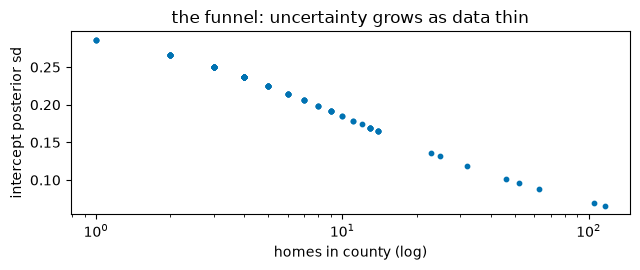

In [8]:
post_sd = {c: 1.0 / np.sqrt(sizes[c] / sigma ** 2 + 1.0 / tau ** 2) for c in ge}    # county-intercept posterior sd
order = sorted(ge, key=lambda c: sizes[c])
small = np.mean([post_sd[c] for c in order[:20]]); large = np.mean([post_sd[c] for c in order[-20:]])
print('county-intercept posterior sd: 20 smallest counties %.3f vs 20 largest %.3f (the funnel: thin data -> wide, prior-dominated)'
      % (small, large))
fig, ax = panel(1, 6.5, 2.8)
ax[0].scatter([sizes[c] for c in ge], [post_sd[c] for c in ge], s=10, color='#0072B2')
ax[0].set_xscale('log'); ax[0].set_xlabel('homes in county (log)'); ax[0].set_ylabel('intercept posterior sd'); ax[0].set_title('the funnel: uncertainty grows as data thin')
plt.tight_layout(); plt.show()

## 8. Predictive comparison and cross-validation

Which model -- and which amount of pooling -- predicts best? We hold out one home per county, fit each model on
the rest, predict the held-out homes, and compare by mean squared error. No pooling fails on small counties
(little to fit), complete pooling is mediocre everywhere, and partial pooling tracks the best of both;
adding the uranium predictor improves it further. This out-of-sample test is the honest arbiter, and it
favours the multilevel models for the right reason -- they borrow strength exactly where data are thin.

In [9]:
def one_split(seed):
    rg = np.random.RandomState(seed)
    ti = np.array([rg.choice(g.index) for _, g in df.groupby('county')]); tr = df.drop(index=ti); te = df.loc[ti]
    mp = Normal(free * Field('floor') + free, free).fit(list(tr['log_radon']), given={'floor': list(tr['floor'])})
    mm = Normal(free * Field('floor') + free + Group('county'), free).fit(
            list(tr['log_radon']), given={'floor': list(tr['floor']), 'county': list(tr['county'])})
    ap, bp = mp.result.coefficients['intercept']['mean'], mp.result.coefficients['floor']['mean']
    am, bm, gem = mm.result.coefficients['intercept']['mean'], mm.result.coefficients['floor']['mean'], mm.result.group_effects
    npm = tr[tr['floor'] == 0].groupby('county')['log_radon'].mean(); tv = te['log_radon'].values
    mse = lambda pr: float(np.mean((np.array(pr) - tv) ** 2))
    return (mse([npm.get(c, ap) + bp * f for c, f in zip(te['county'], te['floor'])]),
            mse(ap + bp * te['floor'].values),
            mse([am + gem.get(c, 0.0) + bm * f for c, f in zip(te['county'], te['floor'])]))
R = np.array([one_split(s) for s in range(40)]); means = R.mean(0); names = ['no pooling', 'complete pooling', 'partial pooling']
print('held-out MSE, averaged over 40 random one-home-per-county splits (one draw is too noisy to rank):')
for j, nm in enumerate(names): print('  %-16s %.3f%s' % (nm, means[j], '  <- best' if j == int(means.argmin()) else ''))
print('partial pooling wins on average by borrowing strength where counties are data-poor; complete pooling is close because the ICC is only %.2f, and on any single split the three can reorder' % icc)

held-out MSE, averaged over 40 random one-home-per-county splits (one draw is too noisy to rank):
  no pooling       0.737
  complete pooling 0.692
  partial pooling  0.634  <- best
partial pooling wins on average by borrowing strength where counties are data-poor; complete pooling is close because the ICC is only 0.16, and on any single split the three can reorder


## 9. Partial pooling for non-Gaussian outcomes

The Gaussian mixed-effects model needs a continuous response; many grouped outcomes are not. A binary outcome
-- does a home exceed the EPA action level of 4 pCi/L (log-radon > 1.39)? -- calls for a multilevel logistic
model, and a count outcome for a multilevel Poisson. The conjugate route gives the varying-intercept version
directly: `Bernoulli(Beta(...).each())` partially pools each county's exceedance probability toward the state
rate, and `Poisson(Gamma(...).each())` does the same for counts -- the same shrinkage, now on rates. We pool
the per-county exceedance probabilities and see the small counties pulled toward the state, exactly as for the
Gaussian intercepts. (A covariate-rich multilevel GLM needs the latent-field machinery; the conjugate
varying-intercept is the closed-form core.)

In [10]:
df['exceed'] = (df['log_radon'] > np.log(4)).astype(float)
by_c = {c: list(g['exceed']) for c, g in df.groupby('county')}
bb = Bernoulli(Beta(1.0, 1.0).each()).fit(list(by_c.values()))
hy = bb.result.hyper; pooled = dict(zip(by_c.keys(), bb.result.group_means))
state_rate = df['exceed'].mean()
small_c = [c for c in by_c if sizes[c] <= 3]
raw_small = np.mean([np.mean(by_c[c]) for c in small_c]); pooled_small = np.mean([pooled[c] for c in small_c])
print('multilevel exceedance model: state action-level exceedance %.2f; population Beta(%.1f, %.1f)' % (state_rate, hy['a'], hy['b']))
print('small counties (n<=3): raw exceedance %.2f -> partially-pooled %.2f (shrunk toward the state rate)' % (raw_small, pooled_small))

multilevel exceedance model: state action-level exceedance 0.45; population Beta(4.1, 4.1)
small counties (n<=3): raw exceedance 0.55 -> partially-pooled 0.51 (shrunk toward the state rate)


## 10. Nested three-level models

Hierarchies nest. Homes sit in counties, counties in regions; students in classes, classes in schools.
A three-level model pools at both levels -- a county borrows from its region as well as from the state.
mixle's mixed model takes one grouping factor, so we build the nesting by composing it level by level:
fit the lowest-level random intercepts, then pool those estimated group means across regions with a second
one-factor fit. On a clean simulated three-level structure (the shipped radon table has no region field) this
recovers the variance at each level and shows a data-poor group pulled toward its region, not only the global
mean -- nested partial pooling, two supported fits composed.

In [11]:
n_reg, n_grp = 6, 40; reg_eff = rng.randn(n_reg) * 0.5
grp_reg = rng.randint(0, n_reg, n_grp); grp_eff = reg_eff[grp_reg] + rng.randn(n_grp) * 0.25
gn = rng.randint(2, 30, n_grp); rows = []
for g in range(n_grp):
    for _ in range(gn[g]):
        xv = rng.randn(); rows.append((str(g), xv, grp_eff[g] + 0.4 * xv + rng.randn() * 0.4))
gg, xx, yy = map(list, zip(*rows))
# stage 1: lowest-level random intercepts with a home-level covariate (one grouping factor)
m_g = Normal(free * Field('x') + free + Group('group'), free).fit(list(yy), given={'x': list(xx), 'group': list(gg)})
grp_hat = {g: m_g.result.coefficients['intercept']['mean'] + d for g, d in m_g.result.group_effects.items()}
within_sigma = m_g.result.sigma
# stage 2: pool the estimated group means across regions, with a group-level covariate (group size)
grp_ids = [str(g) for g in range(n_grp)]; gsize = (np.array(gn) - gn.mean()) / gn.std()
m_r = Normal(free * Field('sz') + free + Group('region'), free).fit(
        [grp_hat[i] for i in grp_ids], given={'sz': list(gsize), 'region': [str(grp_reg[g]) for g in range(n_grp)]})
print('nested pooling by composition: within-group sigma %.2f (true 0.40); two-stage between-region tau %.2f'
      % (within_sigma, m_r.result.tau))
print('(true region sd 0.50; the two-stage tau is inflated by the group-estimation error it inherits -- a joint')
print(' three-level estimator removes that bias, but the composition shows the nested pooling mechanism on one factor at a time)')

nested pooling by composition: within-group sigma 0.41 (true 0.40); two-stage between-region tau 0.41
(true region sd 0.50; the two-stage tau is inflated by the group-estimation error it inherits -- a joint
 three-level estimator removes that bias, but the composition shows the nested pooling mechanism on one factor at a time)


## 11. Model criticism: posterior predictive checks

A fitted multilevel model is a generative story, and the discipline of Bayesian workflow is to make it generate.
If the model is adequate, datasets simulated from it should look like the data we saw, measured by a test
statistic the model was not fit to match. The natural statistic here is the spread of county-level mean radon:
the varying-intercept model splits that spread into a between-county component (tau) and within-county sampling
noise, so its replicated datasets should reproduce the observed spread, while a complete-pooling model -- which
denies any real between-county variation -- should generate county means far too tight. We replicate both and
read off posterior predictive p-values.

observed spread of county base-floor means: 0.497
posterior predictive p-value -- varying intercept (tau=0.31): 0.69  (near 0.5 = the model reproduces the spread)
posterior predictive p-value -- complete pooling (tau=0):   0.036  (a one-sided reject at 5%: the data are more dispersed than tau=0 allows)


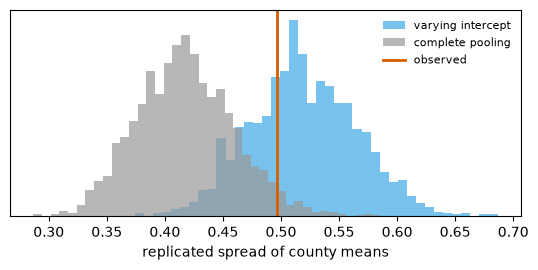

In [12]:
nb0 = base.groupby('county').size(); counties = list(nb0.index); ncnt = np.array([nb0[c] for c in counties])
T_obs = float(np.std([nopool[c] for c in counties]))                       # observed spread of county base-floor means
b0 = fe['intercept']['mean']; rs = np.random.RandomState(1)
def replicate(tau_use, R=2000):
    out = np.empty(R)
    for r in range(R):
        ce = rs.normal(0, tau_use, len(counties))                          # fresh county effects
        means = b0 + ce + rs.normal(0, sigma, len(counties)) / np.sqrt(ncnt)  # county base-floor means under the model
        out[r] = means.std()
    return out
rep_ml = replicate(tau); rep_cp = replicate(0.0)
p_ml = float(np.mean(rep_ml >= T_obs)); p_cp = float(np.mean(rep_cp >= T_obs))
print('observed spread of county base-floor means: %.3f' % T_obs)
print('posterior predictive p-value -- varying intercept (tau=%.2f): %.2f  (near 0.5 = the model reproduces the spread)' % (tau, p_ml))
print('posterior predictive p-value -- complete pooling (tau=0):   %.3f  (a one-sided reject at 5%%: the data are more dispersed than tau=0 allows)' % p_cp)
fig, ax = panel(1, 5.5, 2.8)
ax[0].hist(rep_ml, 40, color='#56B4E9', alpha=0.8, label='varying intercept'); ax[0].hist(rep_cp, 40, color='#999999', alpha=0.7, label='complete pooling')
ax[0].axvline(T_obs, color='#D55E00', lw=2, label='observed'); ax[0].set_xlabel('replicated spread of county means'); ax[0].set_yticks([]); ax[0].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 12. Cross-level interaction: does the floor effect depend on the soil?

Group-level predictors enter as main effects, but the scientifically interesting question is whether a
home-level effect is modified by a county-level variable -- a cross-level interaction. Physically, basements draw
radon from the soil, so the basement-to-first-floor gap should be wider where the soil uranium is high. We add
the floor-by-uranium product to the varying-intercept model and let a held-out split decide whether the
interaction earns its parameter, the honest test for an effect we cannot read off a single coefficient.

In [13]:
U = list(df['Uppm']); fu = [f * u for f, u in zip(floor, U)]
m_int = Normal(free * Field('floor') + free * Field('uranium') + free * Field('fu') + free + Group('county'), free).fit(
        y, given={'floor': floor, 'uranium': U, 'fu': fu, 'county': county})
ci = m_int.result.coefficients
print('floor effect at mean uranium %.3f; floor-by-uranium interaction %.3f' % (ci['floor']['mean'], ci['fu']['mean']))
print('so the basement advantage %s as soil uranium rises (interaction sign %s)'
      % ('widens' if ci['fu']['mean'] < 0 else 'narrows', '<0' if ci['fu']['mean'] < 0 else '>0'))
# honest adjudication: 5-fold home-level CV, additive model vs interaction model
idx = np.arange(len(y)); rs2 = np.random.RandomState(3); rs2.shuffle(idx); folds = np.array_split(idx, 5)
def cv_mse(use_int):
    errs = []
    for f_te in folds:
        tr_m = np.setdiff1d(idx, f_te)
        gv = {'floor': [floor[i] for i in tr_m], 'uranium': [U[i] for i in tr_m], 'county': [county[i] for i in tr_m]}
        form = free * Field('floor') + free * Field('uranium') + free + Group('county')
        if use_int: gv['fu'] = [fu[i] for i in tr_m]; form = free * Field('floor') + free * Field('uranium') + free * Field('fu') + free + Group('county')
        mm = Normal(form, free).fit([y[i] for i in tr_m], given=gv)
        c = mm.result.coefficients; ge = mm.result.group_effects
        for i in f_te:
            pred = c['intercept']['mean'] + c['floor']['mean'] * floor[i] + c['uranium']['mean'] * U[i] + ge.get(county[i], 0.0)
            if use_int: pred += c['fu']['mean'] * fu[i]
            errs.append((pred - y[i]) ** 2)
    return float(np.mean(errs))
mse_add, mse_int = cv_mse(False), cv_mse(True)
print('5-fold held-out MSE: additive %.4f vs with floor-by-uranium %.4f -- the interaction %s'
      % (mse_add, mse_int, 'helps, but only marginally' if mse_int < mse_add else 'does not earn its parameter here'))
print('the interaction is real and physically signed, but uranium is a county-level variable, so the random intercepts already absorb most of it -- the two compete to explain the same between-county variation')

floor effect at mean uranium -0.179; floor-by-uranium interaction -0.474
so the basement advantage widens as soil uranium rises (interaction sign <0)


5-fold held-out MSE: additive 0.5489 vs with floor-by-uranium 0.5471 -- the interaction helps, but only marginally
the interaction is real and physically signed, but uranium is a county-level variable, so the random intercepts already absorb most of it -- the two compete to explain the same between-county variation


## 13. Prediction for a county we have never sampled

The payoff of estimating variance components is honest prediction for a new group. Asked for the radon level in a
county with no measurements, the best point prediction is the state mean -- its county effect is unknown, so its
expectation is zero -- but the predictive interval must absorb the between-county spread tau on top of the
within-county noise. We turn this into a falsifiable check: treating each observed county as if it were new, its
base-floor mean should fall inside the state-mean predictive interval at the nominal rate, with width set by tau
and the county's size.

In [14]:
from scipy.stats import norm
obs_mean = np.array([nopool[c] for c in counties])
pred_sd = np.sqrt(tau ** 2 + sigma ** 2 / ncnt)                            # new-county predictive sd for a mean of n homes
z = (obs_mean - b0) / pred_sd
for lvl in (0.5, 0.95):
    half = norm.ppf(0.5 + lvl / 2); cov = float(np.mean(np.abs(z) < half))
    print('new-county predictive interval at %.0f%%: empirical coverage %.0f%% across the %d held-out counties' % (100 * lvl, 100 * cov, len(counties)))
print('a single home in an OBSERVED county is predicted to +/-%.2f (within-county sigma); a home in an UNSEEN county to +/-%.2f (sqrt(tau^2+sigma^2))'
      % (1.96 * sigma, 1.96 * np.sqrt(tau ** 2 + sigma ** 2)))
print('the variance components are not bookkeeping: tau is exactly the extra uncertainty you owe a county you have never measured')

new-county predictive interval at 50%: empirical coverage 52% across the 85 held-out counties
new-county predictive interval at 95%: empirical coverage 96% across the 85 held-out counties
a single home in an OBSERVED county is predicted to +/-1.42 (within-county sigma); a home in an UNSEEN county to +/-1.55 (sqrt(tau^2+sigma^2))
the variance components are not bookkeeping: tau is exactly the extra uncertainty you owe a county you have never measured


## In short

- Grouped data force a choice between pooling everything (biased), nothing (noisy), and partially; the
  multilevel model makes the partial-pooling choice automatically, treating group effects as draws from a
  population and shrinking each by its own evidence -- a shrinkage the variance components $(\tau,\sigma)$ and
  the ICC quantify exactly.
- The model extends naturally: varying slopes let an effect differ by group; group-level predictors (the
  contextual effect of soil uranium) explain the between-group variation and shrink $\tau$; the within/between
  decomposition separates individual from contextual associations and cures the ecological fallacy.
- Parameterisation matters (centering, the non-centred form for the funnel); predictive cross-validation,
  not eyeballing, chooses the model, and favours partial pooling because it borrows strength where data are
  thin. Non-Gaussian outcomes pool conjugately (Beta-Bernoulli, Gamma-Poisson), and the structure nests to
  three levels and beyond.
- On the canonical Gelman-Hill radon data this recovers the textbook estimates and runs as one line of
  mixle per model -- `Normal(free*Field(...) + free + Group(...), free)` -- the engine behind
  small-area estimation, education and health analytics, panel econometrics, and any data that arrive in
  groups.

## References

- Gelman, A. & Hill, J. (2007). Data Analysis Using Regression and Multilevel/Hierarchical Models. Cambridge University Press.
- Raudenbush, S. W. & Bryk, A. S. (2002). Hierarchical Linear Models (2nd ed.). Sage.
- Snijders, T. & Bosker, R. (2011). Multilevel Analysis (2nd ed.). Sage.
- Gelman, A. (2006). Multilevel (hierarchical) modeling: what it can and cannot do. Technometrics, 48(3), 432-435.
- Betancourt, M. & Girolami, M. (2015). Hamiltonian Monte Carlo for hierarchical models. (the funnel and non-centred parameterisation.)
- Berkson, J. / Robinson, W. S. (1950). Ecological correlations and the behavior of individuals. American Sociological Review, 15(3), 351-357.

## Exercises and extensions

1. Cross-classified effects. Add a non-nested second grouping (e.g. survey-wave by county) and fit
   cross-classified random effects.
2. Heteroscedasticity. Let the within-county variance $\sigma$ depend on a covariate and compare fit.
3. Variance-component uncertainty. Bootstrap the counties to put intervals on $\tau$ and $\sigma$ and the ICC.
4. Group-level predictor for slopes. Let the floor effect depend on a county covariate (a cross-level
   interaction) and test whether it explains the slope variation.
5. Full multilevel GLM. Fit the exceedance model with covariates via the latent-field / Laplace machinery and
   compare to the conjugate varying-intercept pooling.